In [310]:
import pandas as pd
import seaborn as sns

# scikit-learn imports
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [311]:
raw_dataframe = pd.read_csv("../data/raw/Extracted Desciption Data - Dummy Complexity Score.csv")

In [312]:
raw_dataframe.head()

,ID,Job Title,Job Description,Sum of Weights,Sum of (Complexity x Skill),Complexity Score,Amount,Currency,Country,Country Category
0,4,Build API access to data,Project Title: Build API access to acquired fl...,830,2730,3.289157,500,USD,United Kingdom,High income
1,100,Multimodal Neural Network for Financial Data A...,Project Overview: I am looking to develop a cu...,1590,5670,3.566038,500,USD,United Arab Emirates,High income
2,163,Reconciliation of GST Invoices between two Sou...,I am looking for a skilled developer who can h...,600,1610,2.683333,7000,INR,India,Lower middle income
3,194,Need complex sample tableau dashboards (financ...,Project Description: Complex Sample Tableau Da...,940,2810,2.989362,140,USD,United States,High income
4,256,App Statistics Module Developer Needed,Project Overview: Seeking an experienced app d...,840,2510,2.988095,500,USD,Denmark,High income


## Preprocessing

In [313]:
from helper import convert_to_usd

Convert 'Amount' column that is not USD from 'Currency' to USD.

In [314]:
currency = raw_dataframe["Currency"]
amount = raw_dataframe["Amount"]

raw_dataframe["Amount"] = raw_dataframe.apply(convert_to_usd, axis=1)

Filtering out relevant columns that will be used for modelling.

In [315]:
relevent_columns = [
    "ID",
    "Complexity Score",
    "Amount",
    "Country",
    "Country Category",
]

filtered_dataframe = raw_dataframe[relevent_columns].copy()

In [316]:
# # Remove salary outliers using z-score threshold of 3.
# amount_mean = filtered_dataframe["Amount"].mean()
# amount_std = filtered_dataframe["Amount"].std(ddof=0)

# if amount_std != 0:
#     amount_z_scores = (filtered_dataframe["Amount"] - amount_mean) / amount_std
#     filtered_dataframe = filtered_dataframe[amount_z_scores.abs() <= 3].copy()

## Data Exploration

Distribution of complexity score.

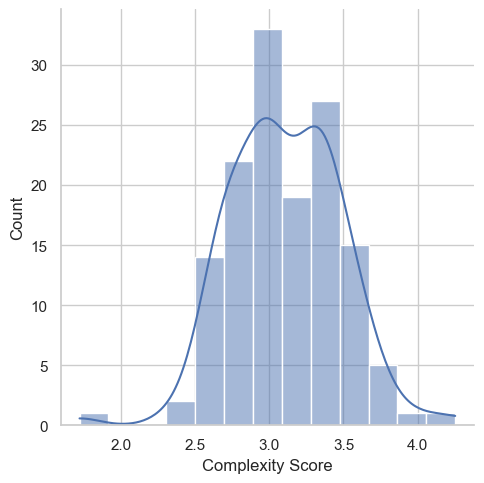

In [317]:
data = filtered_dataframe[["Complexity Score"]]
sns.displot(data=data, x="Complexity Score", kde=True)

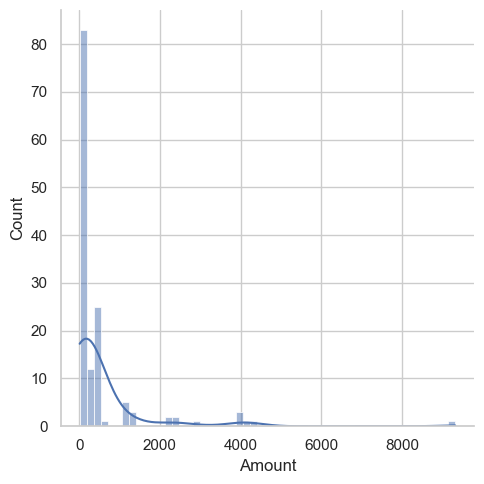

In [318]:
salaries = filtered_dataframe[["Amount"]]
sns.displot(data=salaries, x="Amount", kde=True)

<Axes: xlabel='Amount', ylabel='Complexity Score'>

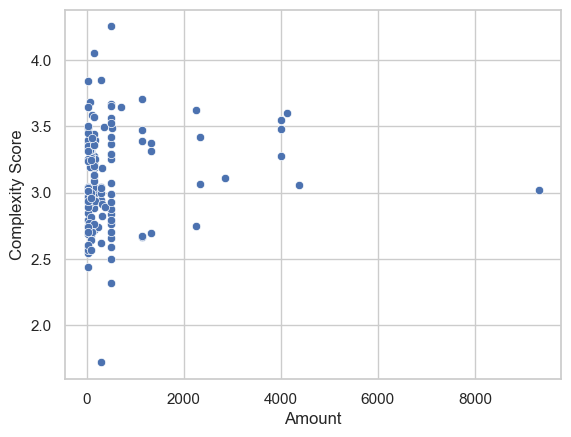

In [319]:

sns.scatterplot(data=filtered_dataframe, x="Amount", y="Complexity Score")

Average salaries from country categories

,Country Category,Amount
2,Upper middle income,892.441905
0,High income,547.048147
1,Lower middle income,375.885340


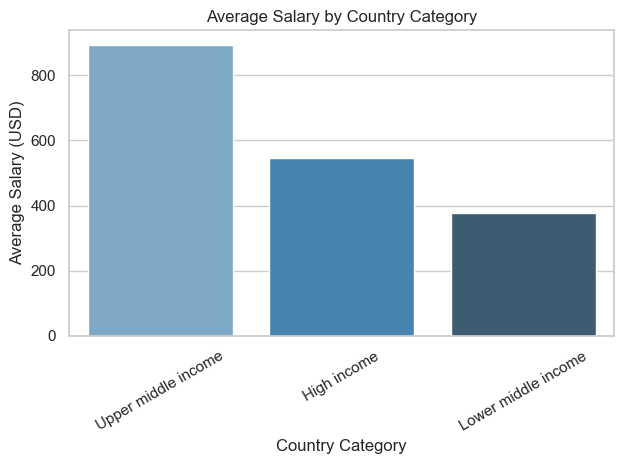

In [320]:
sns.set_theme(style="whitegrid")

avg_salaries_by_country_category = (
    filtered_dataframe.groupby("Country Category", as_index=False)["Amount"]
    .mean()
    .sort_values("Amount", ascending=False)
)

ax = sns.barplot(
    data=avg_salaries_by_country_category,
    x="Country Category",
    y="Amount",
    palette="Blues_d",
    hue="Country Category",
    dodge=False,
    legend=False,
)
ax.set_title("Average Salary by Country Category")
ax.set_xlabel("Country Category")
ax.set_ylabel("Average Salary (USD)")
ax.tick_params(axis="x", rotation=30)
ax.figure.tight_layout()

avg_salaries_by_country_category

## Modelling
we'll be performing multi-variate regression

### Method 1: Without Normalization

In [321]:
# Predict complexity score directly from raw (non-normalized) features.
dataset_without_normalization = filtered_dataframe.drop(columns=["ID"]).copy()
X = dataset_without_normalization[["Complexity Score", "Country Category", "Country"]]
y = dataset_without_normalization["Amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [322]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), ["Country Category", "Country"]),
    ],
    remainder="passthrough",
    sparse_threshold=0,
    verbose_feature_names_out=False,
)

In [323]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [324]:
results = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": root_mean_squared_error(y_test, y_pred),
    "R2": r2_score(y_test, y_pred),
}

results

{'MAE': 584.3486722110207,
 'MSE': 1093506.863292703,
 'RMSE': 1045.7087851274382,
 'R2': 0.08216731845248515}

### Method 2: With Normalization
Normalization will be applied according to Country Category 

In [325]:
# Normalize Amount column according to Country Category
dataset_with_normalization = filtered_dataframe.drop(columns=["ID"]).copy()

# Calculate mean and std for Amount per Country Category
amount_stats = dataset_with_normalization.groupby("Country Category")["Amount"].agg(["mean", "std"])

# Apply z-score normalization per Country Category
def normalize_amount(row):
    country_cat = row["Country Category"]
    amount = row["Amount"]
    mean = amount_stats.loc[country_cat, "mean"]
    std = amount_stats.loc[country_cat, "std"]
    return (amount - mean) / std if std != 0 else 0

dataset_with_normalization["Amount"] = dataset_with_normalization.apply(normalize_amount, axis=1)

X = dataset_with_normalization[["Complexity Score", "Country"]]
y = dataset_with_normalization["Amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [326]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), ["Country"]),
    ],
    remainder="passthrough",
    sparse_threshold=0,
    verbose_feature_names_out=False,
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)


In [327]:
# model = LinearRegression()

In [328]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [329]:
results = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": root_mean_squared_error(y_test, y_pred),
    "R2": r2_score(y_test, y_pred),
}

results

{'MAE': 0.5585567245543939,
 'MSE': 1.068135227611689,
 'RMSE': 1.0335062784577989,
 'R2': 0.03133209066629672}

# Conclusion